In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
input_folder = r"C:\study\codes\DSIP"

image1 = cv2.imread(os.path.join(input_folder, "img1.png"))
image2 = cv2.imread(os.path.join(input_folder, "img2.png"))
image3 = cv2.imread(os.path.join(input_folder, "img3.png"))
image4 = cv2.imread(os.path.join(input_folder, "img4.png"))
image5 = cv2.imread(os.path.join(input_folder, "img5.png"))

images = [image1, image2, image3, image4, image5]

for i, img in enumerate(images, 1):
    if img is None:
        print("Image", i, "not found")
    else:
        print("Image", i, "loaded successfully")

Image 1 loaded successfully
Image 2 loaded successfully
Image 3 loaded successfully
Image 4 loaded successfully
Image 5 loaded successfully


In [ ]:
gray_images = []

for i, img in enumerate(images):
  if img is None:
    print(f'Warning: Image at index {i} is None or empty. Skipping.')
    continue

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  gray_images.append(gray)

print('All valid images converted to grayscale')


In [ ]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(gray_images, 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title("Image " + str(i))
    plt.axis("off")

plt.tight_layout()
plt.show()

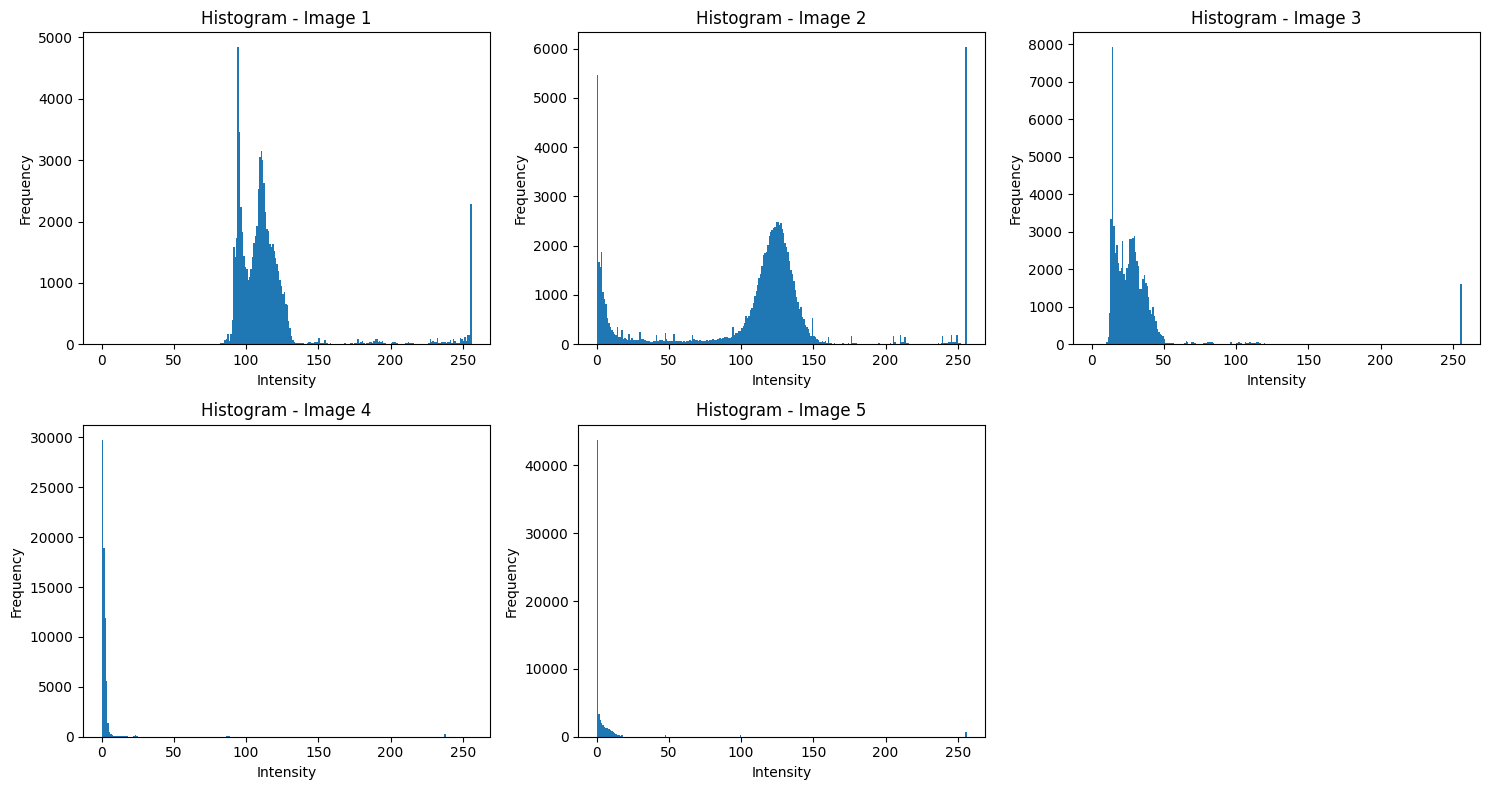

In [15]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(gray_images, 1):
    plt.subplot(2, 3, i)

    plt.hist(
        img.ravel(),
        bins=256,
        range=[0, 256]
    )

    plt.title("Histogram - Image " + str(i))
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:



equalized_images = []

for img in gray_images:

    equalized = cv2.equalizeHist(img)

    equalized_images.append(equalized)

print("Histogram equalization completed for all five images")

Histogram equalization completed for all five images


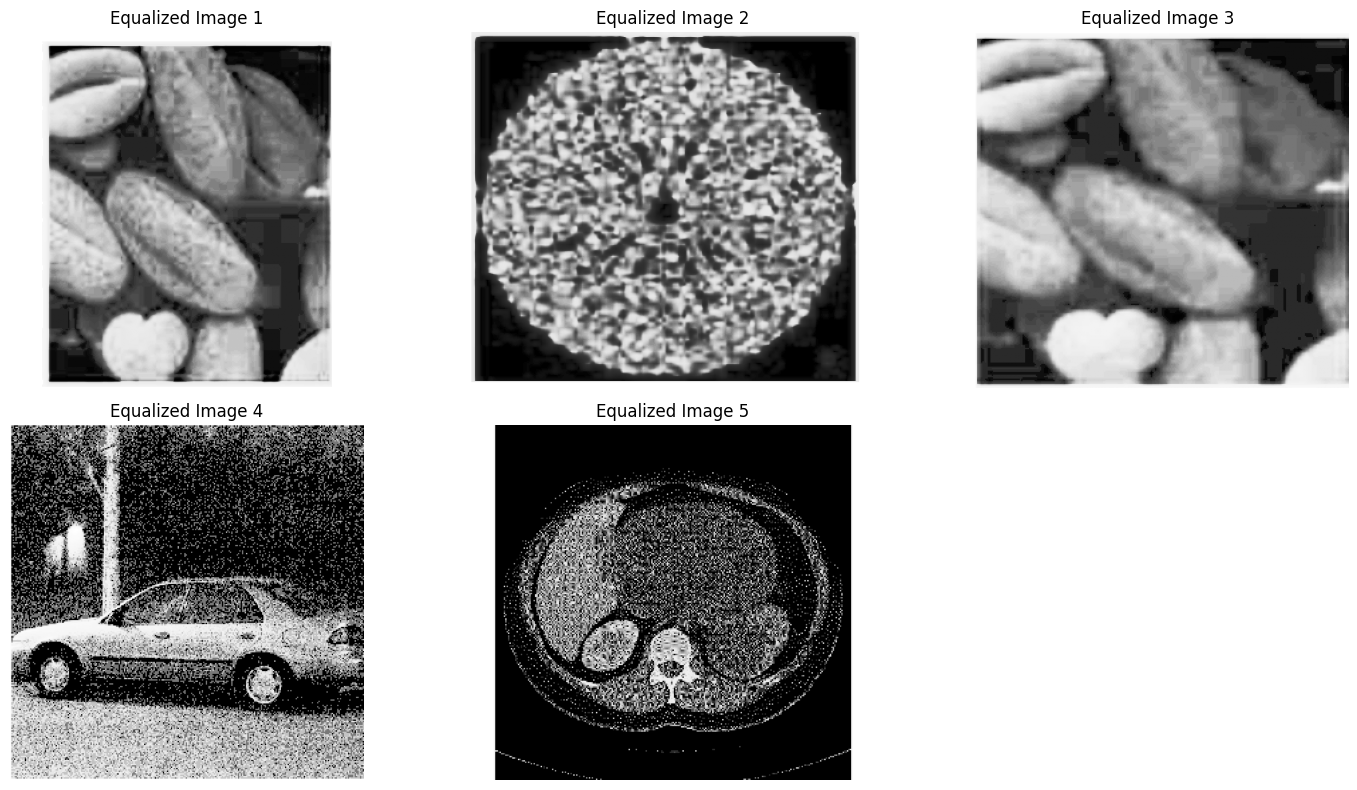

In [18]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(equalized_images, 1):

    plt.subplot(2, 3, i)

    plt.imshow(img, cmap="gray")

    plt.title("Equalized Image " + str(i))

    plt.axis("off")

plt.tight_layout()
plt.show()

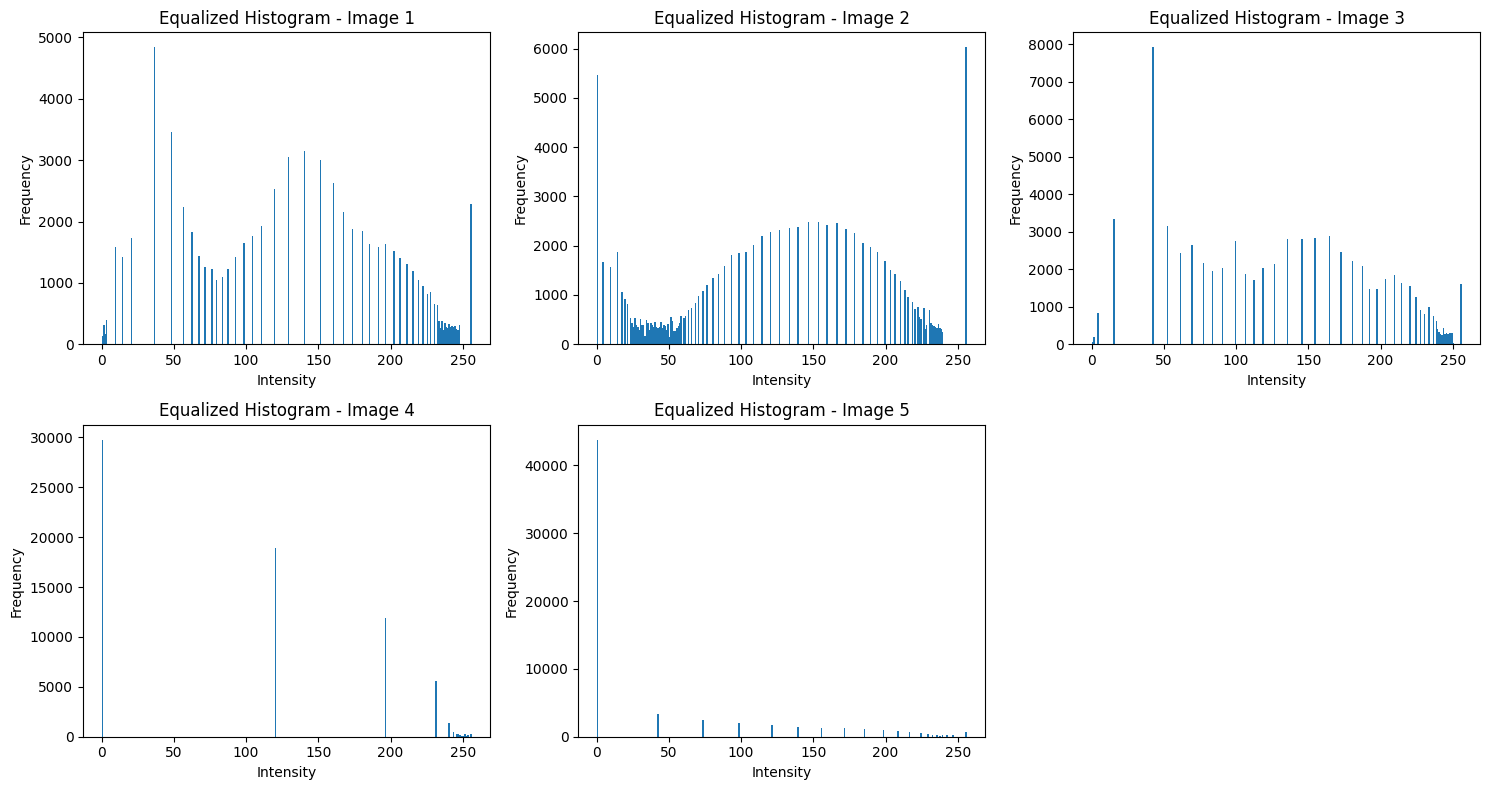

In [19]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(equalized_images, 1):

    plt.subplot(2, 3, i)

    plt.hist(
        img.ravel(),
        bins=256,
        range=[0, 256]
    )

    plt.title("Equalized Histogram - Image " + str(i))

    plt.xlabel("Intensity")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [43]:
from skimage.exposure import match_histograms

In [44]:
matched_images = []

for img in gray_images:

    matched = match_histograms(
        img,
        reference_gray
    )

    matched = np.clip(
        matched,
        0,
        255
    ).astype(np.uint8)

    matched_images.append(matched)

print("Histogram matching completed for all five images")

Histogram matching completed for all five images


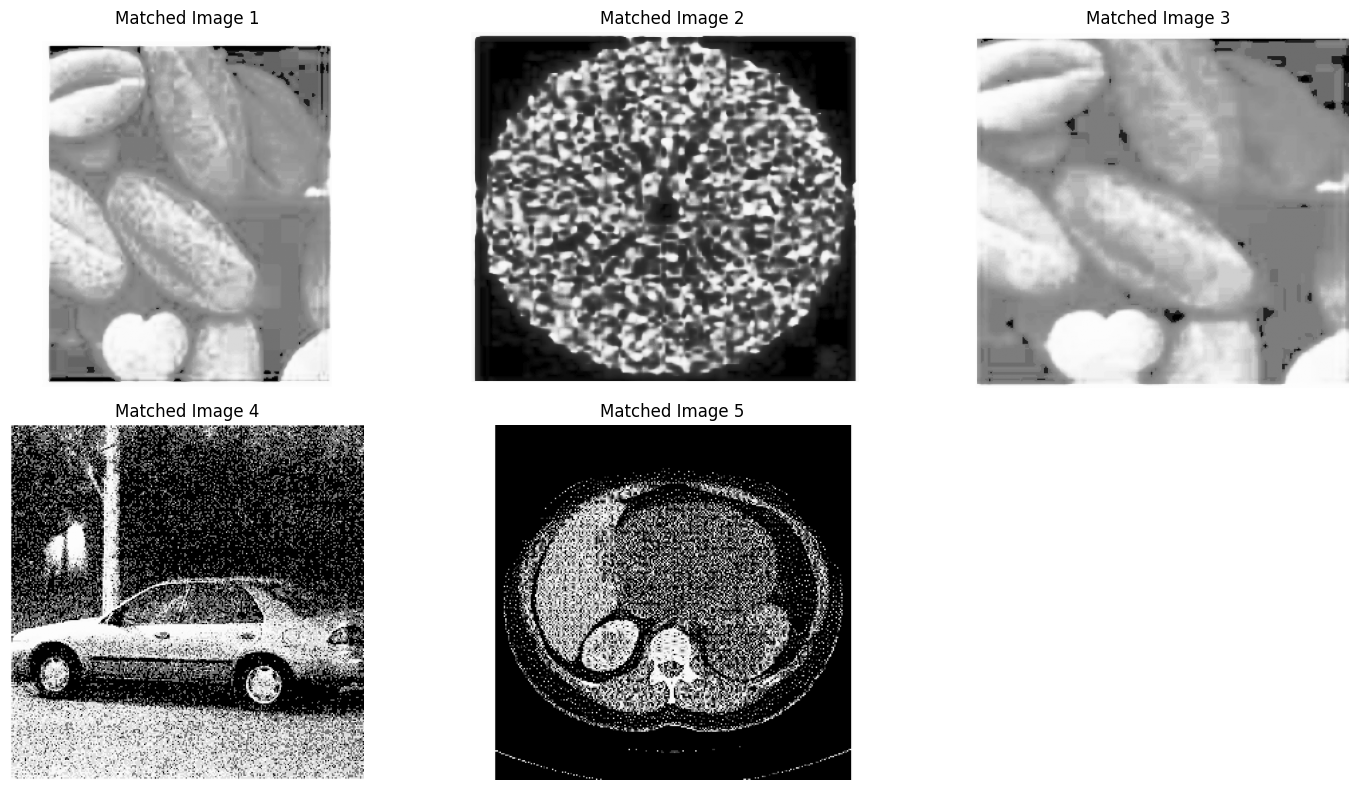

In [45]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(matched_images, 1):

    plt.subplot(2, 3, i)

    plt.imshow(img, cmap="gray")

    plt.title("Matched Image " + str(i))

    plt.axis("off")

plt.tight_layout()
plt.show()

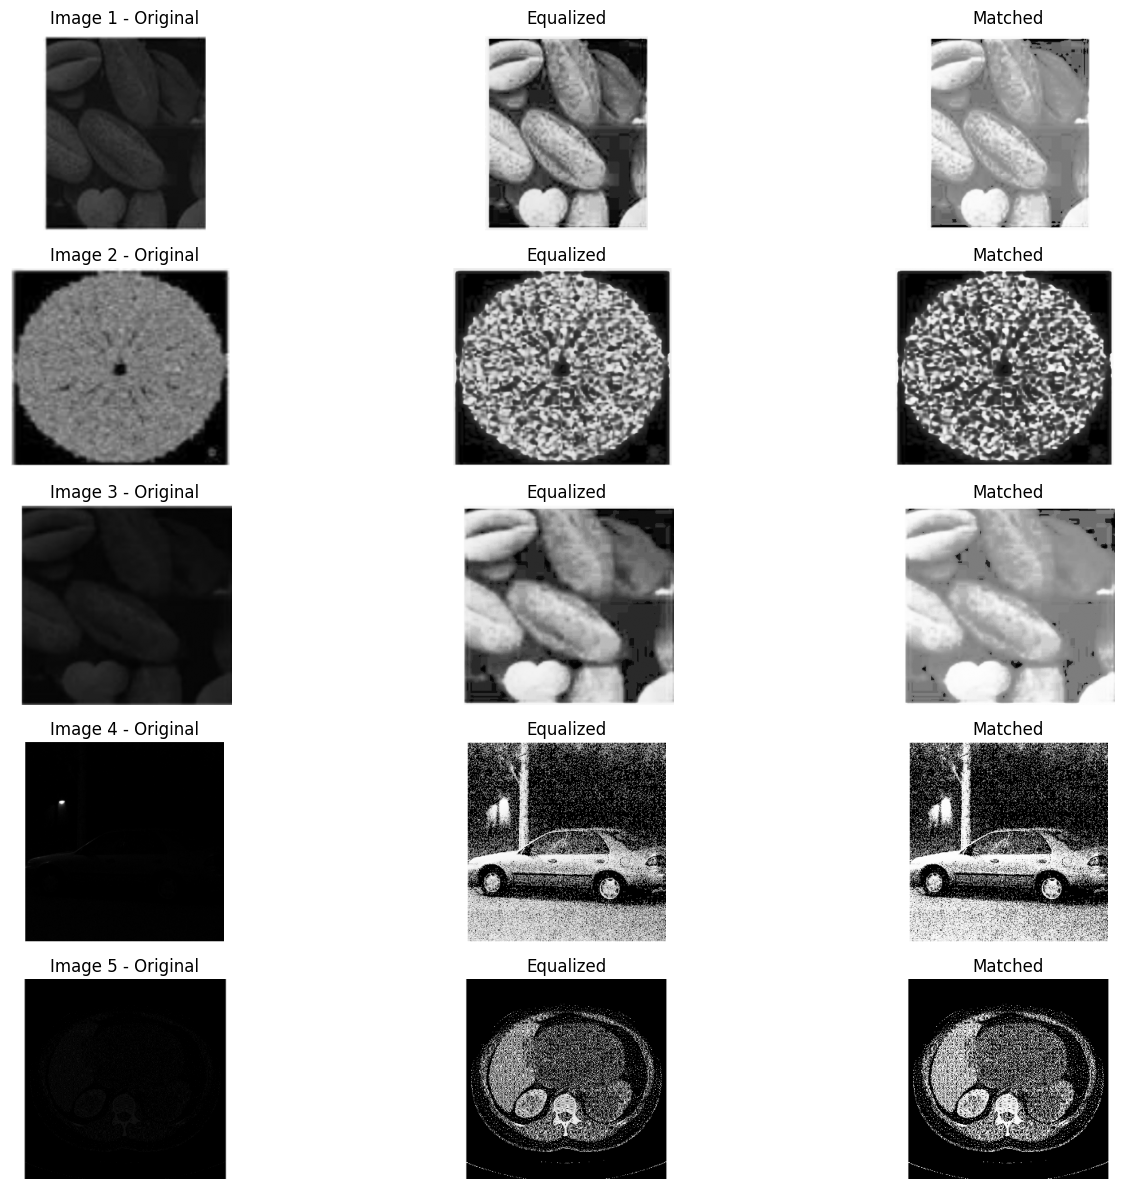

In [46]:
plt.figure(figsize=(15, 12))

for i in range(5):

    plt.subplot(5, 3, i * 3 + 1)

    plt.imshow(gray_images[i], cmap="gray")

    plt.title("Image " + str(i + 1) + " - Original")

    plt.axis("off")


    plt.subplot(5, 3, i * 3 + 2)

    plt.imshow(equalized_images[i], cmap="gray")

    plt.title("Equalized")

    plt.axis("off")


    plt.subplot(5, 3, i * 3 + 3)

    plt.imshow(matched_images[i], cmap="gray")

    plt.title("Matched")

    plt.axis("off")

plt.tight_layout()
plt.show()

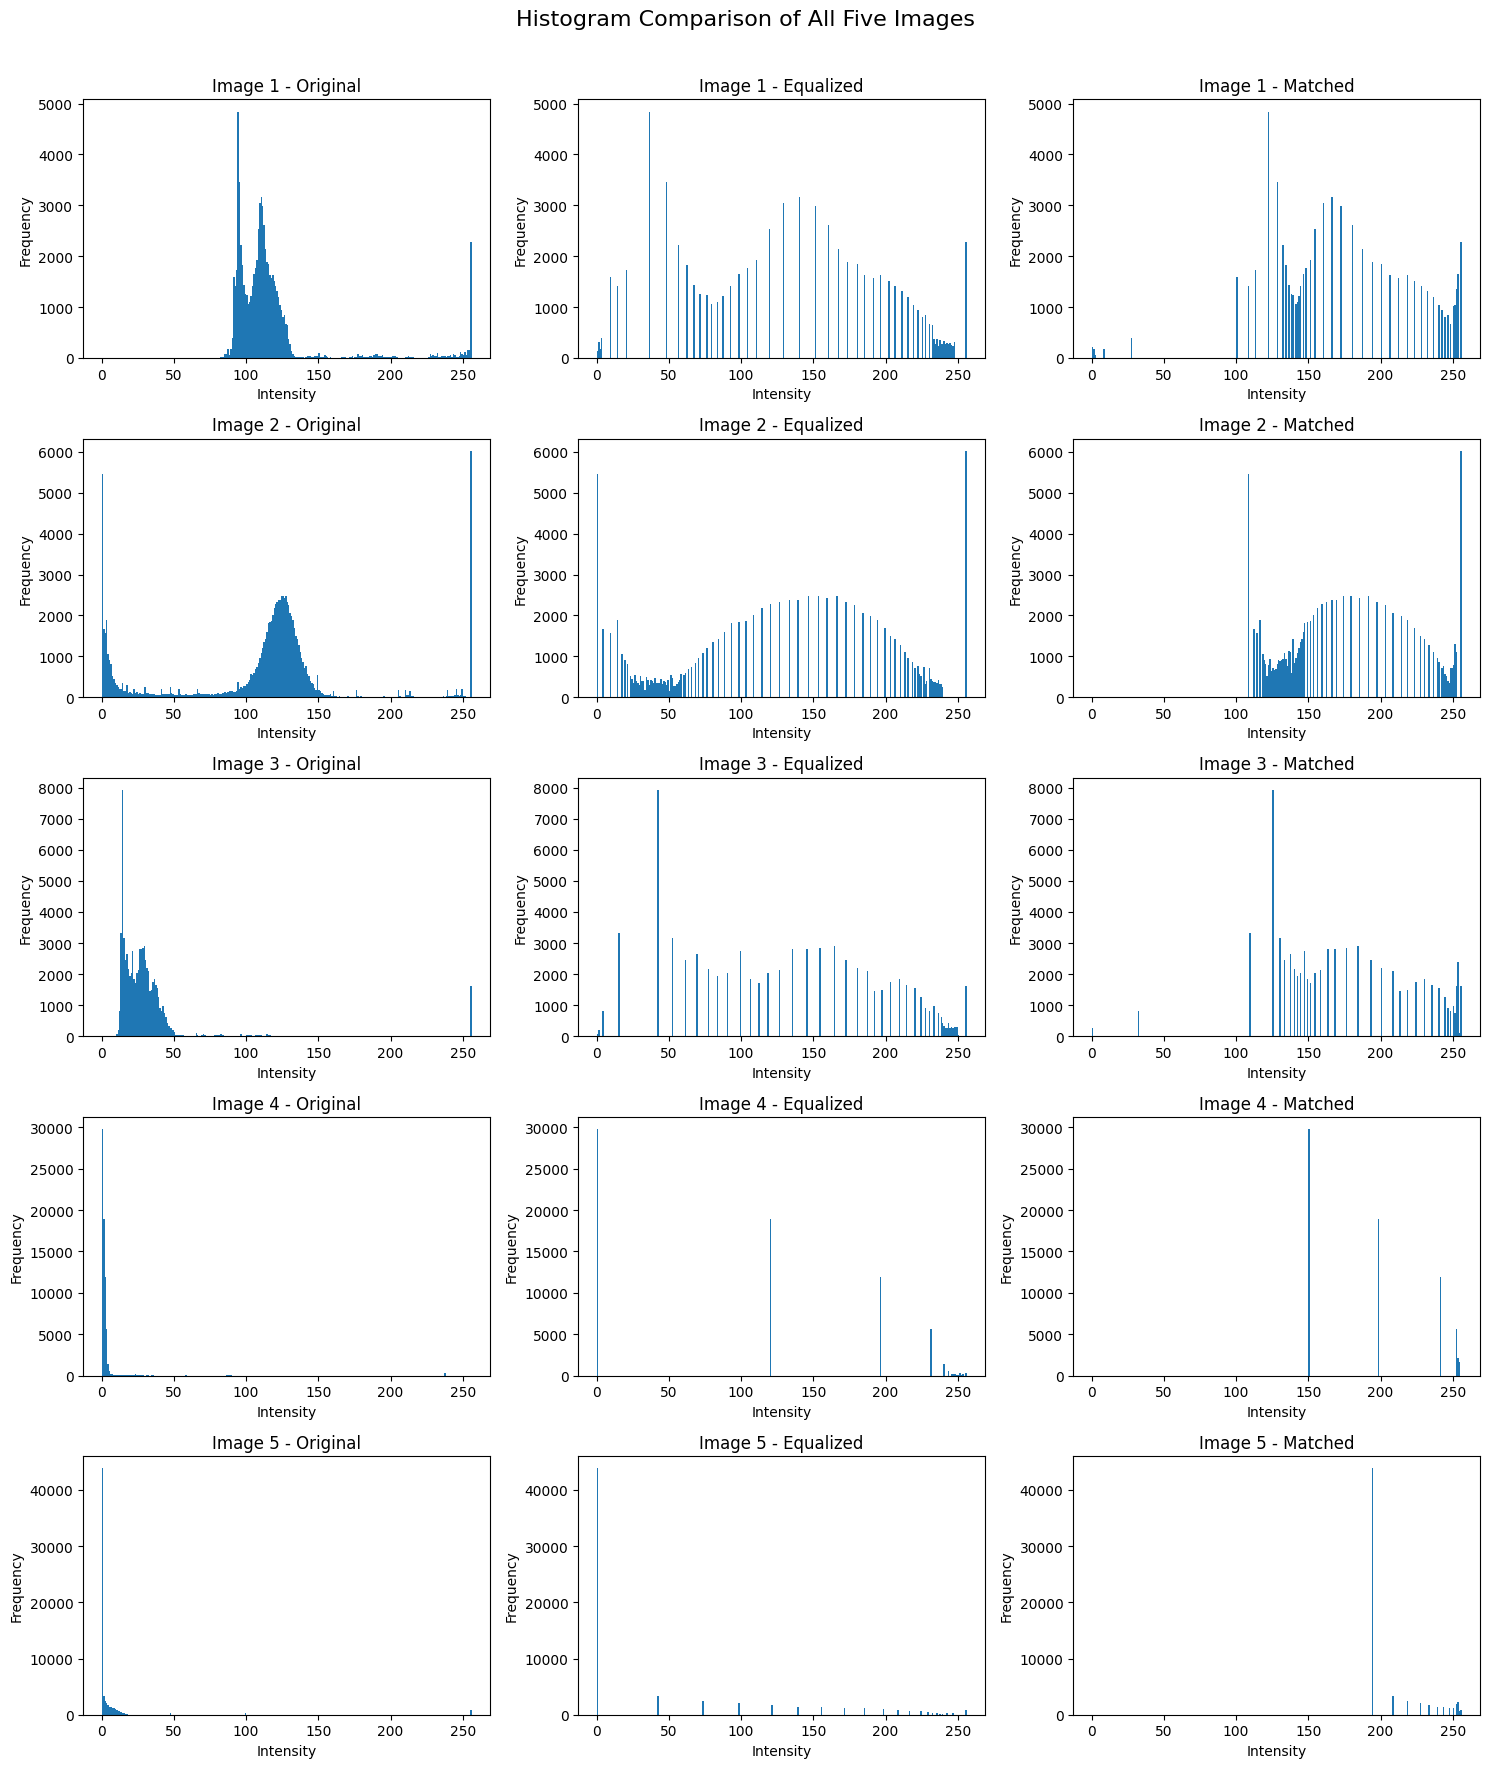

In [55]:
plt.figure(figsize=(15, 18))

for i in range(5):

    # Original
    plt.subplot(5, 3, i * 3 + 1)
    plt.hist(
        gray_images[i].ravel(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"Image {i+1} - Original")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")

    # Histogram Equalization
    plt.subplot(5, 3, i * 3 + 2)
    plt.hist(
        equalized_images[i].ravel(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"Image {i+1} - Equalized")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")

    # Histogram Matching
    plt.subplot(5, 3, i * 3 + 3)
    plt.hist(
        matched_images[i].ravel(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"Image {i+1} - Matched")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")

plt.suptitle(
    "Histogram Comparison of All Five Images",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [56]:
def calculate_statistics(image):

    mean = np.mean(image)

    std = np.std(image)

    minimum = np.min(image)

    maximum = np.max(image)

    return mean, std, minimum, maximum

In [57]:
for i in range(5):

    original = calculate_statistics(gray_images[i])

    equalized = calculate_statistics(
        equalized_images[i]
    )

    matched = calculate_statistics(
        matched_images[i]
    )

    print("\nImage", i + 1)

    print("Original :", original)

    print("Equalized:", equalized)

    print("Matched  :", matched)


Image 1
Original : (np.float64(116.52663813061972), np.float64(34.88590372214834), np.uint8(82), np.uint8(255))
Equalized: (np.float64(130.95742475636678), np.float64(72.77299256499715), np.uint8(0), np.uint8(255))
Matched  : (np.float64(172.4141361115598), np.float64(49.60372352700661), np.uint8(0), np.uint8(255))

Image 2
Original : (np.float64(108.8949812644503), np.float64(62.41552429588396), np.uint8(0), np.uint8(255))
Equalized: (np.float64(122.8194809854102), np.float64(78.19388202809547), np.uint8(0), np.uint8(255))
Matched  : (np.float64(173.0703380371522), np.float64(46.88567349624937), np.uint8(108), np.uint8(255))

Image 3
Original : (np.float64(31.69445621094991), np.float64(35.67357544372849), np.uint8(7), np.uint8(255))
Equalized: (np.float64(132.1144366197183), np.float64(71.45062049642492), np.uint8(0), np.uint8(255))
Matched  : (np.float64(173.2572275759822), np.float64(48.604925791589956), np.uint8(0), np.uint8(255))

Image 4
Original : (np.float64(2.541981132075471